# Washington State GHG Emissions: Who Bears the Burden?

**AD450 Final Project — Daniel Rice, Daniel Merced, Phakphoom, Veer**

## Thesis
The burden of industrial greenhouse gas emissions falls unevenly across Washington State. Rural, lower-income counties bear a disproportionate per-capita emissions load compared to wealthier, more populated urban counties.

## Datasets
1. **WA GHG Reporting Program** — Facility-level emissions reported to the state (2012–2023). Source: [data.wa.gov](https://data.wa.gov/)
2. **US Census County Population Estimates** — Annual county population (2012–2023). Source: [census.gov](https://www.census.gov/programs-surveys/popest/data/data-sets.html)
3. **SAIPE Income & Poverty Estimates** — Median household income and poverty rate by county (2024 snapshot). Source: [census.gov SAIPE](https://www.census.gov/programs-surveys/saipe.html)

## Guiding Questions
1. Which counties emit the most greenhouse gases *per person*, and how does that differ from total emissions?
2. How have emissions changed over time across different sectors?
3. Is there a relationship between a county's median income and its per-capita emissions burden?
4. Which industrial sectors dominate emissions in the counties that bear the heaviest per-capita burden?

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
!pip install xlrd

In [3]:
# Read the GHG raw data
ghg_url = "https://data.wa.gov/api/views/idhm-59de/rows.csv?accessType=DOWNLOAD"
ghg_path = "./data/raw/GHG_Reporting_Program_Publication.csv"

if os.path.exists(ghg_path):
    ghg_raw = pd.read_csv(ghg_path)
else:
    ghg_raw = pd.read_csv(ghg_url)
    ghg_raw.to_csv(ghg_path, index=False)

ghg_raw.head()


,Reporter,Year,Sector,Subsector,Primary NAICS Code,NAICS Definition,Parent Company,City,County,Jurisdiction,...,HFCs (MTCO2e),PFCs (MTCO2e),Sulfur Hexafluoride (MTCO2e),Fluorinated - Other (MTCO2e),Notes,Point Size,Location,Covered Emissions (MT CO2e),CCA Status,Georeferenced Location
0,Northwest Hardwoods Inc. - Centralia,2022,Wood Products,Lumber Mills,321113.0,Sawmills,Littlejohn & Co. LLC,Centralia,Lewis,Southwest Clean Air Agency,...,0.0,0.0,0.0,0.0,NaN,1.0,"46.734454, -122.991963",NaN,NaN,POINT (-122.991963 46.734454)
1,Seattle-Tacoma International Airport - Seattle,2021,Government,Other Government,488119.0,Other Airport Operations,Port of Seattle,Seattle,King,Puget Sound Clean Air Agency,...,0.0,0.0,0.0,0.0,NaN,1.0,"47.443643, -122.302452",NaN,NaN,POINT (-122.302452 47.443643)
2,Avista Corporation - supplier,2018,Supplier,Natural Gas Supplier,NaN,NaN,Avista Corporation,Spokane,Spokane,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Avista - EPE - Spokane,2022,Power,IOU,NaN,NaN,Avista Corporation,Spokane,Spokane,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Public Utility District No. 1 of Grays Harbor ...,2022,Power,COU,2211.0,"Electric Power Generation, Transmission and Di...",Public Utility District No. 1 of Grays Harbor ...,Aberdeen,Grays Harbor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Census Data Sets

# Data for 2020-2024
raw_census_2020_to_2024 = pd.read_excel("data/raw/co-est2024-pop-53.xlsx", skiprows=3, header=0)

# Data for 2010-2019
raw_census_2010_to_2019 = pd.read_excel("data/raw/co-est2020int-pop-53.xlsx", skiprows=3, header=0)

In [5]:
# Income Data Sets

raw_income = pd.read_excel("data/raw/est24all.xls", skiprows=3, header=0)

---
## 2. Exploratory Data Analysis (EDA)

Before cleaning or joining anything, we explore the raw GHG dataset to understand its shape, contents, and quirks.

### 2.1 Summarize the data (Daniel Rice)
Use `.info()`, `.shape`, and `.head()` to understand the structure of the GHG dataset — column names, dtypes, non-null counts, and a preview of actual values.

In [6]:
# TODO (Daniel Rice): Summarize ghg_raw — .shape, .info(), .head()
print(ghg_raw.info())

print(ghg_raw.shape)

print(ghg_raw.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226 entries, 0 to 2225
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Reporter                          2226 non-null   object 
 1   Year                              2226 non-null   int64  
 2   Sector                            2225 non-null   object 
 3   Subsector                         2225 non-null   object 
 4   Primary NAICS Code                2198 non-null   float64
 5   NAICS Definition                  2198 non-null   object 
 6   Parent Company                    2216 non-null   object 
 7   City                              2225 non-null   object 
 8   County                            2225 non-null   object 
 9   Jurisdiction                      1994 non-null   object 
 10  Reported Emissions (MTCO2e)       2223 non-null   float64
 11  Biogenic Carbon Dioxide (MTCO2e)  2159 non-null   float64
 12  Carbon

### 2.2 Basic statistics on numeric columns (Daniel Merced)
Use `.describe()` on the numeric emissions columns. What is the range of reported emissions? What does the distribution look like (mean vs median)? Are there zeros?

In [7]:
# TODO (Daniel Merced): .describe() on numeric columns, especially emissions columns
# Note any large differences between mean and median (indicates skew/outliers)

# numeric emissions-related columns
emissions_numeric = ghg_raw.select_dtypes(include="number")

# summary statistics
emissions_numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2226.0,2018.005391,3.549707e+00,2012.0,2015.0,2018.0,2021.0,2023.0
Primary NAICS Code,2198.0,360493.103276,1.559330e+05,2211.0,311411.0,322130.0,424710.0,928110.0
Reported Emissions (MTCO2e),2223.0,251384.089519,7.754844e+05,0.0,16188.5,36801.0,106314.5,8911628.0
Biogenic Carbon Dioxide (MTCO2e),2159.0,42790.459009,1.752620e+05,0.0,0.0,0.0,0.0,1627697.0
Carbon Dioxide (MTCO2e),2159.0,192749.316813,7.443682e+05,0.0,1975.0,17582.0,61764.0,8415579.0
Methane (MTCO2e),2159.0,8533.169060,3.178184e+04,0.0,10.0,63.0,2059.5,348592.0
Nitrous Oxide (MTCO2e),2159.0,2151.232978,1.146719e+04,0.0,8.0,27.0,374.5,176178.0
HFCs (MTCO2e),2159.0,65.098657,7.438371e+02,0.0,0.0,0.0,0.0,11841.0
PFCs (MTCO2e),2159.0,3553.637795,4.863256e+04,0.0,0.0,0.0,0.0,884344.0
Sulfur Hexafluoride (MTCO2e),2159.0,290.912923,2.667460e+03,0.0,0.0,0.0,0.0,45978.0


### 2.3 Value counts of categorical columns (Phakphoom)
Use `.value_counts()` on Sector, County, and City to understand the categorical distribution. How many unique sectors? Which counties appear most often? Are there any unexpected values (e.g., out-of-state counties)?

In [8]:
# TODO (Phakphoom): value_counts() for Sector, County, and City

# Create a summary DataFrame for missing and unique values
summary_df = pd.DataFrame({
    "Missing Values": ghg_raw[["Sector", "County", "City"]].isnull().sum(),
    "Unique Values": ghg_raw[["Sector", "County", "City"]].nunique()
})

print("Summary of Missing and Unique Values:")
display(summary_df)

# Display value counts for Sector, County, and City
for column in ["Sector", "County", "City"]:
    print(f"\n--- {column} Distribution ---")
    
    if column == "Sector":
        display(ghg_raw[column].value_counts())
    else:
        display(ghg_raw[column].value_counts().head(20))

# Indentify unique counties and compare against known WA counties
display(pd.Series(ghg_raw["County"].unique()).sort_values())

# List of WA counties for reference
wa_counties = [
    "King", "Pierce", "Snohomish", "Spokane", "Clark", "Thurston",
    "Kitsap", "Yakima", "Whatcom", "Benton", "Skagit", "Cowlitz",
    "Grant", "Franklin", "Island", "Lewis", "Clallam", "Chelan",
    "Douglas", "Kittitas", "Walla Walla", "Whitman", "Stevens",
    "Okanogan", "Pacific", "Grays Harbor", "Skamania", "Asotin",
    "Pend Oreille", "Adams", "Columbia", "Garfield", "Jefferson",
    "Mason", "San Juan", "Ferry", "Lincoln", "Wahkiakum"
]

unexpected_counties = ghg_raw[
    ~ghg_raw["County"].isin(wa_counties)
]["County"].value_counts()

print("Counties in GHG data not in WA county list:")
display(unexpected_counties)

# Count how many entries have counties not in the WA list
invalid_count = ghg_raw[~ghg_raw["County"].isin(wa_counties)].shape[0]
total_count = ghg_raw.shape[0]

print(f"Entries with invalid counties: {invalid_count} out of {total_count}")

# Display entries with unexpected counties for further inspection
print("\nEntries with unexpected counties:")
display(ghg_raw[~ghg_raw["County"].isin(wa_counties)])

# Distribution of states
print("Raw Income Data - Postal Code Distribution:")
display(raw_income["Postal Code"].value_counts())

# Count non-WA entries
print("Raw Income Data - Postal Code Distribution:")
non_wa_count = (raw_income["Postal Code"] != "WA").sum()
display(non_wa_count)

# Inspect unexpected states
print("\nNon-WA Postal Codes in Raw Income Data:")
display(raw_income[raw_income["Postal Code"] != "WA"]["Postal Code"].value_counts())



Summary of Missing and Unique Values:


,Missing Values,Unique Values
Sector,1,16
County,1,69
City,1,130



--- Sector Distribution ---


Sector
Food Production        264
Power Plants           255
Wood Products          245
Natural Gas Systems    206
Pulp and Paper         176
Supplier               167
Waste                  167
Manufacturing          159
Government             139
Petroleum Systems      105
Minerals                82
Metals                  75
Power                   64
Chemicals               60
Livestock               54
Health Care              7
Name: count, dtype: int64


--- County Distribution ---


...

Postal Code
TX    255
GA    160
VA    134
KY    121
MO    116
KS    106
IL    103
NC    101
IA    100
TN     96
NE     94
IN     93
OH     89
MN     88
MI     84
MS     83
OK     78
AR     76
WI     73
FL     68
PA     68
AL     68
SD     67
LA     65
CO     65
NY     63
CA     59
MT     57
WV     56
ND     54
SC     47
ID     45
WA     40
OR     37
NM     34
AK     31
UT     30
MD     25
WY     24
NJ     22
NV     18
ME     17
AZ     16
MA     15
VT     15
NH     11
CT     10
RI      6
HI      6
DE      4
DC      2
US      1
Name: count, dtype: int64

Raw Income Data - Postal Code Distribution:


np.int64(3156)


Non-WA Postal Codes in Raw Income Data:


Postal Code
TX    255
GA    160
VA    134
KY    121
MO    116
KS    106
IL    103
NC    101
IA    100
TN     96
NE     94
IN     93
OH     89
MN     88
MI     84
MS     83
OK     78
AR     76
WI     73
PA     68
FL     68
AL     68
SD     67
LA     65
CO     65
NY     63
CA     59
MT     57
WV     56
ND     54
SC     47
ID     45
OR     37
NM     34
AK     31
UT     30
MD     25
WY     24
NJ     22
NV     18
ME     17
AZ     16
MA     15
VT     15
NH     11
CT     10
RI      6
HI      6
DE      4
DC      2
US      1
Name: count, dtype: int64

### 2.4 Histograms of numeric columns (Veer)
Plot histograms of `Reported Emissions (MTCO2e)` and at least one gas breakdown column (e.g., Carbon Dioxide, Methane). Are emissions normally distributed or heavily skewed?

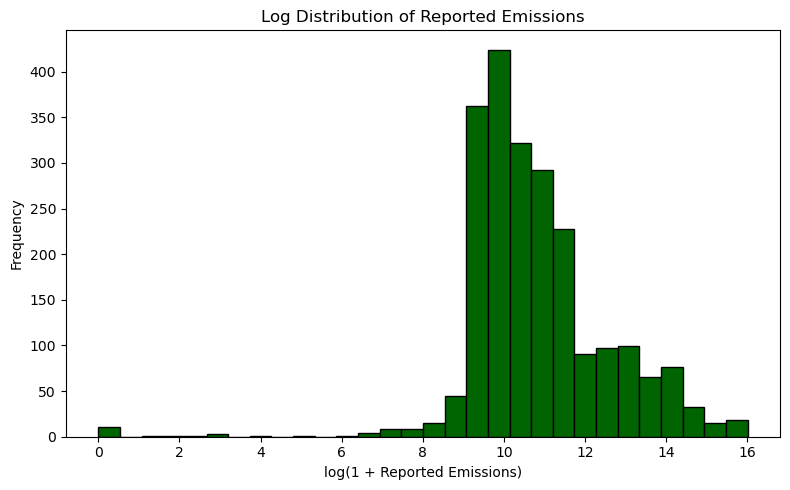

In [9]:
# TODO (Veer): Histograms of Reported Emissions and at least one gas breakdown column
# Consider using log scale if the distribution is extremely skewed

# Log histogram for Reported Emissions
plt.figure(figsize=(8,5))
plt.hist(
    np.log1p(ghg_raw['Reported Emissions (MTCO2e)'].dropna()),
    bins=30,
    color='darkgreen',
    edgecolor='black'
)
plt.title('Log Distribution of Reported Emissions')
plt.xlabel('log(1 + Reported Emissions)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

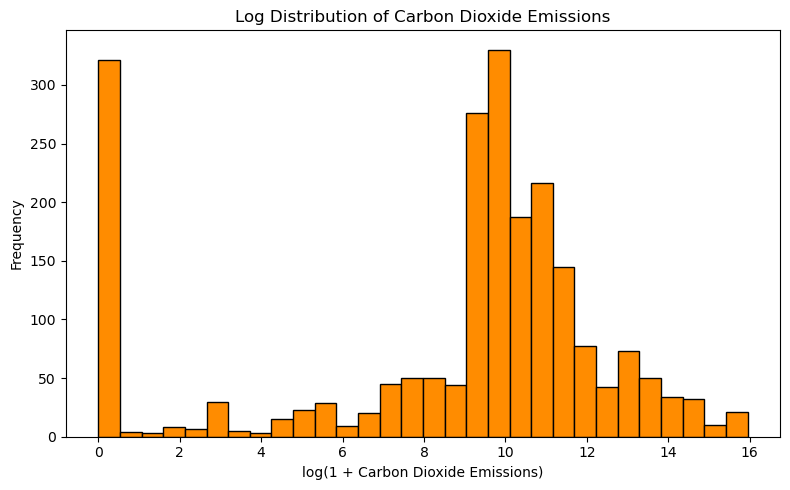

In [10]:
# Log histogram for Carbon Dioxide
plt.figure(figsize=(8,5))
plt.hist(
    np.log1p(ghg_raw['Carbon Dioxide (MTCO2e)'].dropna()),
    bins=30,
    color='darkorange',
    edgecolor='black'
)
plt.title('Log Distribution of Carbon Dioxide Emissions')
plt.xlabel('log(1 + Carbon Dioxide Emissions)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---
## 3. Data Cleaning & Transformation

The raw data has null values, dtype issues, out-of-state rows, and columns we need to derive. We clean all three datasets in this section.

### 3.1 Correct data dtype issues (Daniel Rice)
- Ensure `Year` is int (not float).
- Parse the `Location` column (lat, lon string) into separate `Latitude` and `Longitude` float columns.
- Fix `Primary NAICS Code` to a clean numeric or string type.
- Also clean the census population dataframes: rename the first column to `County`, strip the leading dot and trailing `, Washington` from county names, drop the state total row, and ensure year columns are int.

In [11]:
# TODO (Daniel Rice): Fix dtypes in ghg_raw
# Also clean raw_census_2010_to_2019 and raw_census_2020_to_2024:
#   - Rename first col to 'County'
#   - Strip leading '.' and trailing ' County, Washington' from county names
#   - Drop the state total row (first data row = 'Washington')
#   - Keep only year columns we need (2012-2019 from the first file, 2020-2023 from the second)

# === Fix dtypes in ghg_raw ===

# Year is already int64, confirmed via .info() — no fix needed

# Parse Location column ("lat, lon" string) into separate float columns
ghg_raw[['Latitude', 'Longitude']] = (
    ghg_raw['Location']
    .str.split(',', expand=True)
    .astype(float)
)

# Clean NAICS code — drop decimal, convert to nullable Int64
ghg_raw['Primary NAICS Code'] = ghg_raw['Primary NAICS Code'].astype('Int64')


# === Clean census 2010-2019 ===

# Rename first column
raw_census_2010_to_2019 = raw_census_2010_to_2019.rename(columns={raw_census_2010_to_2019.columns[0]: 'County'})

# Drop state total row
raw_census_2010_to_2019 = raw_census_2010_to_2019[raw_census_2010_to_2019['County'] != 'Washington']

# Clean county names: ".Adams County, Washington" -> "Adams"
raw_census_2010_to_2019['County'] = (
    raw_census_2010_to_2019['County']
    .str.lstrip('.')
    .str.replace(' County, Washington', '', regex=False)
)

# Keep only 2012-2019 columns (drop 2010, 2011, April 2020 Census, and the April 2010 base)
year_cols_2010s = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
census_2012_2019 = raw_census_2010_to_2019[['County'] + year_cols_2010s].copy()


# === Clean census 2020-2024 ===

raw_census_2020_to_2024 = raw_census_2020_to_2024.rename(columns={raw_census_2020_to_2024.columns[0]: 'County'})
raw_census_2020_to_2024 = raw_census_2020_to_2024[raw_census_2020_to_2024['County'] != 'Washington']

raw_census_2020_to_2024['County'] = (
    raw_census_2020_to_2024['County']
    .str.lstrip('.')
    .str.replace(' County, Washington', '', regex=False)
)

# Keep only 2020-2023 (drop April 2020 base and 2024)
year_cols_2020s = [2020, 2021, 2022, 2023]
census_2020_2023 = raw_census_2020_to_2024[['County'] + year_cols_2020s].copy()

### 3.2 Fill NaN values (Daniel Merced)
The gas breakdown columns (Carbon Dioxide, Methane, Nitrous Oxide, HFCs, PFCs, SF6, Fluorinated-Other) have 67 null rows each. Decide on a fill strategy:
- If the row has a `Reported Emissions` value but missing breakdowns, fill gas columns with 0 (they weren't reported, not necessarily absent).
- The `Jurisdiction` column has ~232 nulls — fill with `'Unknown'` or investigate.
- Document your reasoning.

In [12]:
# TODO (Daniel Merced): Fill NaN values in emissions breakdown columns and Jurisdiction
# Print null counts before and after to show the work

gas_cols = [
    "Biogenic Carbon Dioxide (MTCO2e)",
    "Carbon Dioxide (MTCO2e)",
    "Methane (MTCO2e)",
    "Nitrous Oxide (MTCO2e)",
    "HFCs (MTCO2e)",
    "PFCs (MTCO2e)",
    "Sulfur Hexafluoride (MTCO2e)",
    "Fluorinated - Other (MTCO2e)"
]

reported_col = "Reported Emissions (MTCO2e)"
jurisdiction_col = "Jurisdiction"

# null counts before
print("Null counts before fill:\n")
print(ghg_raw[gas_cols + [jurisdiction_col]].isna().sum())

# fill gas breakdowns with 0 when total reported emissions exists
has_reported = ghg_raw[reported_col].notna()
ghg_raw.loc[has_reported, gas_cols] = ghg_raw.loc[has_reported, gas_cols].fillna(0)

# fill missing jurisdiction with Unknown
ghg_raw[jurisdiction_col] = ghg_raw[jurisdiction_col].fillna("Unknown")

# null counts after
print("\nNull counts after fill:\n")
print(ghg_raw[gas_cols + [jurisdiction_col]].isna().sum())

# 64 rows had missing gas breakdowns but did have a 
# total reported emissions value, so they were filled with 0
# 3 rows had missing gas breakdowns and also did not have a 
# reported emissions value, so they stayed missing

Null counts before fill:

Biogenic Carbon Dioxide (MTCO2e)     67
Carbon Dioxide (MTCO2e)              67
Methane (MTCO2e)                     67
Nitrous Oxide (MTCO2e)               67
HFCs (MTCO2e)                        67
PFCs (MTCO2e)                        67
Sulfur Hexafluoride (MTCO2e)         67
Fluorinated - Other (MTCO2e)         67
Jurisdiction                        232
dtype: int64

Null counts after fill:

Biogenic Carbon Dioxide (MTCO2e)    3
Carbon Dioxide (MTCO2e)             3
Methane (MTCO2e)                    3
Nitrous Oxide (MTCO2e)              3
HFCs (MTCO2e)                       3
PFCs (MTCO2e)                       3
Sulfur Hexafluoride (MTCO2e)        3
Fluorinated - Other (MTCO2e)        3
Jurisdiction                        0
dtype: int64


### 3.3 Remove inaccurate / out-of-scope data (Phakphoom)
The County value_counts revealed non-WA counties (e.g., `Greater Vancouver`, `Umatilla`, `Sonoma`, `Los Angeles`). These are facilities that report to WA but are physically located elsewhere.
- Identify and remove rows where County is not a valid WA county.
- Also remove the `Supplier` sector rows — these represent fuel suppliers, not physical emitters in a location, and will distort per-capita analysis.
- Document how many rows are removed and why.

In [13]:
# WA counties reference
wa_counties = [
    "Adams", "Asotin", "Benton", "Chelan", "Clallam", "Clark", "Columbia",
    "Cowlitz", "Douglas", "Ferry", "Franklin", "Garfield", "Grant",
    "Grays Harbor", "Island", "Jefferson", "King", "Kitsap", "Kittitas",
    "Klickitat", "Lewis", "Lincoln", "Mason", "Okanogan", "Pacific",
    "Pend Oreille", "Pierce", "San Juan", "Skagit", "Skamania",
    "Snohomish", "Spokane", "Stevens", "Thurston", "Wahkiakum",
    "Walla Walla", "Whatcom", "Whitman", "Yakima"
]

# Track initial size of the dataset before cleaning
raw_count_before_cleaning = len(ghg_raw)

# Normalize County names: strip whitespace, remove " County, Washington" and " County" suffixes
ghg_raw["County"] = (
    ghg_raw["County"]
    .astype(str)
    .str.strip()
    .str.replace(" County, Washington", "", regex=False)
    .str.replace(" County", "", regex=False)
)

# Build masks to identify rows to remove
invalid_county_mask = ~ghg_raw["County"].isin(wa_counties)
supplier_mask = ghg_raw["Sector"].eq("Supplier")

# Diagnostics before removal
out_of_state_counties = (
    ghg_raw.loc[invalid_county_mask, "County"]
    .value_counts()
)

rows_removed_invalid = invalid_county_mask.sum()
rows_removed_supplier = supplier_mask.sum()

# Avoid double counting by taking the union of the two masks
total_rows_removed = (invalid_county_mask | supplier_mask).sum()

# Apply fitering for both conditions in a single step to avoid multiple passes and potential double counting
ghg_raw = ghg_raw.loc[
    ~(invalid_county_mask | supplier_mask)
].copy()

# Drop unnecessary columns that won't be used in analysis (Notes, Latitude, Longitude)
ghg_raw = ghg_raw.drop(
    columns=["Notes", "Latitude", "Longitude"],
    errors="ignore"
)

# Count after cleaning
raw_count_after_cleaning = len(ghg_raw)

# Sanity check
assert raw_count_before_cleaning - raw_count_after_cleaning == total_rows_removed, \
    "Mismatch in removal counts!"

# Create summary table of removed rows
summary_of_removed_rows = pd.DataFrame(
    {
        "Rows Removed": [
            rows_removed_invalid,
            rows_removed_supplier,
            total_rows_removed
        ]
    },
    index=[
        "Invalid Counties",
        "Supplier Sector",
        "Total (Unique Rows Removed)"
    ]
)

print("Row count before cleaning:", raw_count_before_cleaning)
print("Row count after cleaning:", raw_count_after_cleaning)

display(summary_of_removed_rows.head())
display(out_of_state_counties.head(20))

# Clean income data
raw_income_copy = raw_income.copy()

# Count before cleaning
row_count_before_filering_income = len(raw_income_copy)

# Mask for non-WA entries
wa_income_mask = raw_income_copy["Postal Code"].eq("WA")

non_wa_postal_codes = (
    raw_income_copy.loc[~wa_income_mask, "Postal Code"]
    .value_counts()
)

# Count how many non-WA entries
non_wa_count_income = (~wa_income_mask).sum()

# Filter to keep only WA entries
income_clean = raw_income_copy.loc[wa_income_mask].copy()

display(income_clean.loc[income_clean["Name"] == "Washington"])

# Standardize county names for joining
income_clean["County"] = (
        income_clean["Name"]
        .astype(str)
        .str.replace(r"\s+County$", "", regex=True)
        .str.strip()
)

# Keep only county level columns needed for analysis
income_clean = income_clean[[
    "County",
    "Median Household Income",
    "Poverty Percent, All Ages",
]]

# Count after cleaning
row_count_after_filering_income = len(income_clean)

# Sanity check
assert row_count_before_filering_income - row_count_after_filering_income == non_wa_count_income, \
    "Mismatch in removal counts for income data!"

# Create summary table for income data cleaning
summary_income_cleaning = pd.DataFrame(
    {
        "Rows Removed": [non_wa_count_income],
        "Rows Remaining": [row_count_after_filering_income]
    },
    index=["Non-WA Postal Codes"]
)

print("Income Data - Row count before cleaning:", row_count_before_filering_income)
print("Income Data - Row count after cleaning:", row_count_after_filering_income)

display(summary_income_cleaning.head())
display(non_wa_postal_codes.head(20))
display(income_clean.head())
income_clean["County"].nunique()
sorted(income_clean["County"].unique())

Row count before cleaning: 2226
Row count after cleaning: 2031


,Rows Removed
Invalid Counties,130
Supplier Sector,167
Total (Unique Rows Removed),195


County
Multnomah                 28
Harris                    24
MD of Foothills No. 31     8
New York                   4
Dallas                     4
Lambton                    4
Tulsa                      3
Lane                       3
Wasco                      2
Sacramento                 2
Knox                       2
Hancock                    2
San Diego                  2
Kern                       2
Miami-Dade                 2
Nez Perce                  2
Johnson                    2
Greater Vancouver          2
Clackamas                  2
Dakota                     2
Name: count, dtype: int64

,State FIPS Code,County FIPS Code,Postal Code,Name,"Poverty Estimate, All Ages",90% CI Lower Bound,90% CI Upper Bound,"Poverty Percent, All Ages",90% CI Lower Bound.1,90% CI Upper Bound.1,...,90% CI Upper Bound.5,Median Household Income,90% CI Lower Bound.6,90% CI Upper Bound.6,"Poverty Estimate, Age 0-4",90% CI Lower Bound.7,90% CI Upper Bound.7,"Poverty Percent, Age 0-4",90% CI Lower Bound.8,90% CI Upper Bound.8
3003,53,0,WA,Washington,779086,760837,797335,10,9.8,10.2,...,11.7,99309,98035,100583,49473,45048,53898,12.1,11,13.2


Income Data - Row count before cleaning: 3196
Income Data - Row count after cleaning: 40


,Rows Removed,Rows Remaining
Non-WA Postal Codes,3156,40


Postal Code
TX    255
GA    160
VA    134
KY    121
MO    116
KS    106
IL    103
NC    101
IA    100
TN     96
NE     94
IN     93
OH     89
MN     88
MI     84
MS     83
OK     78
AR     76
WI     73
PA     68
Name: count, dtype: int64

,County,Median Household Income,"Poverty Percent, All Ages"
3003,Washington,99309,10
3004,Adams,66089,14.4
3005,Asotin,70914,12.3
3006,Benton,91289,10.6
3007,Chelan,79974,10.2


['Adams',
 'Asotin',
 'Benton',
 'Chelan',
 'Clallam',
 'Clark',
 'Columbia',
 'Cowlitz',
 'Douglas',
 'Ferry',
 'Franklin',
 'Garfield',
 'Grant',
 'Grays Harbor',
 'Island',
 'Jefferson',
 'King',
 'Kitsap',
 'Kittitas',
 'Klickitat',
 'Lewis',
 'Lincoln',
 'Mason',
 'Okanogan',
 'Pacific',
 'Pend Oreille',
 'Pierce',
 'San Juan',
 'Skagit',
 'Skamania',
 'Snohomish',
 'Spokane',
 'Stevens',
 'Thurston',
 'Wahkiakum',
 'Walla Walla',
 'Washington',
 'Whatcom',
 'Whitman',
 'Yakima']

### 3.4 Add derivative columns (Veer)
Create new columns that will power our analysis:
- `Non_CO2_Emissions`: sum of Methane + Nitrous Oxide + HFCs + PFCs + SF6 + Fluorinated-Other (shows how much of each facility's footprint is non-CO2 gases)
- Clean the income data: filter `raw_income` to WA counties only (`State FIPS Code == 53`, `County FIPS Code != 0`), strip `' County'` from the `Name` column, keep only `Name`, `Poverty Percent, All Ages`, and `Median Household Income`.

In [14]:
# TODO (Veer): Add Non_CO2_Emissions column to ghg_raw
# Also clean raw_income into a tidy income_df with columns: County, Poverty_Pct, Median_Income


---
## 4. Data Joining

We now combine our three datasets to enable per-capita and income-based analysis.

### 4.1 Concatenate census population dataframes (Daniel Rice)
Melt each cleaned census dataframe from wide to long format (columns: `County`, `Year`, `Population`), then concatenate them into a single `population_df` covering 2012–2023.
- Watch for the 2020 overlap between the two files — pick one.
- Verify shape: should be 39 counties × 12 years = 468 rows.

In [15]:
# Daniel Rice

# Melt 2012-2019 from wide to long
pop_2012_2019 = census_2012_2019.melt(
    id_vars='County',
    var_name='Year',
    value_name='Population'
)

# Melt 2020-2023 from wide to long
pop_2020_2023 = census_2020_2023.melt(
    id_vars='County',
    var_name='Year',
    value_name='Population'
)

# Ensure Year is int (melt can produce float from Excel headers)
pop_2012_2019['Year'] = pop_2012_2019['Year'].astype(int)
pop_2020_2023['Year'] = pop_2020_2023['Year'].astype(int)

# Concatenate into one population dataframe
population_df = pd.concat([pop_2012_2019, pop_2020_2023], ignore_index=True)

# Verify: 39 counties × 12 years = 468 rows
print("Shape:", population_df.shape)
print(population_df.head())
print(population_df.tail(15))

Shape: (540, 3)
    County  Year  Population
0    Adams  2012     19061.0
1   Asotin  2012     21817.0
2   Benton  2012    182595.0
3   Chelan  2012     73826.0
4  Clallam  2012     71607.0
                                                County  Year  Population
525                                          Snohomish  2023    850297.0
526                                            Spokane  2023    552758.0
527                                            Stevens  2023     48838.0
528                                           Thurston  2023    299519.0
529                                          Wahkiakum  2023      4767.0
530                                        Walla Walla  2023     61789.0
531                                            Whatcom  2023    232686.0
532                                            Whitman  2023     47900.0
533                                             Yakima  2023    257193.0
534  The Census Bureau has reviewed this data produ...  2023         NaN
535  No

### 4.2 Merge GHG data with population on County + Year (Daniel Merced)
Use `pd.merge()` to join the cleaned GHG data with `population_df` on `County` and `Year`. This gives every emissions row a population context.
- Use a left merge to keep all GHG rows.
- Check how many rows have null Population after the merge (counties that don't match).

In [16]:
# (Daniel Merced)
# Merge GHG data with population data on County + Year
ghg_with_population = pd.merge(
    ghg_raw,
    population_df,
    on=["County", "Year"],
    how="left"
)

# Check how many rows did not find a population match
null_population_count = ghg_with_population["Population"].isna().sum()

print("Merged shape:", ghg_with_population.shape)
print("Rows with null Population:", null_population_count)

Merged shape: (2031, 25)
Rows with null Population: 0


### 4.3 Merge with income data on County (Phakphoom)
Use `pd.merge()` to join the income/poverty data onto the GHG+population dataframe on `County`.
- This is a many-to-one join (many GHG rows per county, one income row per county).
- Verify the join worked by spot-checking a known county like King or Lewis.

In [17]:
# Spot-check a couple of counties

# Merge GHG + Population with Income data on County
ghg_population_income = pd.merge(
    ghg_with_population,
    income_clean,
    on="County",
    how="left",
    validate="many_to_one"
)

# Convert income columns to numeric, coercing errors to NaN (should be none after cleaning)
ghg_population_income["Median Household Income"] = pd.to_numeric(
    ghg_population_income["Median Household Income"], errors="coerce"
)

ghg_population_income["Poverty Percent, All Ages"] = pd.to_numeric(
    ghg_population_income["Poverty Percent, All Ages"], errors="coerce"
)

# Merge diagnostics
null_median_income_count = ghg_population_income["Median Household Income"].isna().sum()
null_poverty_pct_count = ghg_population_income["Poverty Percent, All Ages"].isna().sum()

print("Merged shape with income:", ghg_population_income.shape)
print("Rows with null Median Household Income:", null_median_income_count)
print("Rows with null Poverty Percent, All Ages:", null_poverty_pct_count)

# Check for any counties that didn't match
unmatched_counties = (
    ghg_population_income.loc[
        ghg_population_income["Median Household Income"].isna() &
        ghg_population_income["Poverty Percent, All Ages"].isna(),
        "County"
    ]
    .drop_duplicates()
    .sort_values()
)

display(unmatched_counties)

# Sanity check: all unmatched counties should be in the original GHG data but not in the income data

# Merge should not change row count
assert len(ghg_population_income) == len(ghg_with_population), \
    "Row count changed after merging income data"

# No missing income fields after merge
assert ghg_population_income["Median Household Income"].isna().sum() == 0, \
    "There are still missing Median Household Income values after merge"

assert ghg_population_income["Poverty Percent, All Ages"].isna().sum() == 0, \
    "Some rows are missing Poverty Percent, All Ages after merge."

# Each county should map to exactly one income value
income_consistency_check = ghg_population_income.groupby("County")[
    ["Median Household Income", "Poverty Percent, All Ages"]
].nunique()

assert (income_consistency_check["Median Household Income"] == 1).all(), \
    "A county has multiple Median Household Income values."

assert (income_consistency_check["Poverty Percent, All Ages"] == 1).all(), \
    "A county has multiple Poverty Percent values."

# exact duplicate check
exact_duplicate_rows = ghg_population_income.duplicated().sum()
print("Exact duplicate rows:", exact_duplicate_rows)

# each county should map to one income / poverty value
income_consistency_check = ghg_population_income.groupby("County")[
    ["Median Household Income", "Poverty Percent, All Ages"]
].nunique()

assert (income_consistency_check["Median Household Income"] == 1).all()
assert (income_consistency_check["Poverty Percent, All Ages"] == 1).all()

# counties present in income but not in final facility-level table
missing_counties_from_final = sorted(
    set(income_clean["County"]) - set(ghg_population_income["County"])
)
print("WA counties not represented in final GHG table:", missing_counties_from_final)

print("sanity checks passed.")

# Final spot-check of merged data
print("Shape:", ghg_population_income.shape)
display(ghg_population_income.head())
display(ghg_population_income.sample(5, random_state=42))

# Display summary info and null counts for the final merged dataset
display(ghg_population_income.info())

# Check for any remaining null values in the final dataset
null_summary = ghg_population_income.isna().sum().sort_values(ascending=False)
display(null_summary[null_summary > 0])

# Summary statistics for key columns in the final dataset
key_columns = [
    "County",
    "Year",
    "Population",
    "Median Household Income",
    "Poverty Percent, All Ages"
]

display(ghg_population_income[key_columns].describe(include="all"))

# Check the number of unique income values per county to confirm consistency
county_income_variation = ghg_population_income.groupby("County")[
    ["Median Household Income", "Poverty Percent, All Ages"]
].nunique()

display(county_income_variation.sort_values("Median Household Income", ascending=False).head())

year_coverage = ghg_population_income.groupby("County")["Year"].nunique()

display(year_coverage.describe())
display(year_coverage.sort_values().head())

ghg_population_income.loc[
    ghg_population_income["County"].isin(["King", "Yakima", "Spokane"]),
    ["County", "Year", "Population", "Median Household Income", "Poverty Percent, All Ages"]
].sort_values(["County", "Year"]).head(20)

duplicates = ghg_population_income.duplicated(
    subset=["County", "Year", "Sector"], keep=False
)

print("Duplicate rows:", duplicates.sum())

Merged shape with income: (2031, 27)
Rows with null Median Household Income: 0
Rows with null Poverty Percent, All Ages: 0


Series([], Name: County, dtype: object)

Exact duplicate rows: 0
WA counties not represented in final GHG table: ['Ferry', 'Garfield', 'Lincoln', 'San Juan', 'Wahkiakum', 'Washington']
sanity checks passed.
Shape: (2031, 27)


,Reporter,Year,Sector,Subsector,Primary NAICS Code,NAICS Definition,Parent Company,City,County,Jurisdiction,...,Sulfur Hexafluoride (MTCO2e),Fluorinated - Other (MTCO2e),Point Size,Location,Covered Emissions (MT CO2e),CCA Status,Georeferenced Location,Population,Median Household Income,"Poverty Percent, All Ages"
0,Northwest Hardwoods Inc. - Centralia,2022,Wood Products,Lumber Mills,321113,Sawmills,Littlejohn & Co. LLC,Centralia,Lewis,Southwest Clean Air Agency,...,0.0,0.0,1.0,"46.734454, -122.991963",NaN,NaN,POINT (-122.991963 46.734454),85307.0,78178,10.6
1,Seattle-Tacoma International Airport - Seattle,2021,Government,Other Government,488119,Other Airport Operations,Port of Seattle,Seattle,King,Puget Sound Clean Air Agency,...,0.0,0.0,1.0,"47.443643, -122.302452",NaN,NaN,POINT (-122.302452 47.443643),2253242.0,121984,8.8
2,Avista - EPE - Spokane,2022,Power,IOU,<NA>,NaN,Avista Corporation,Spokane,Spokane,Unknown,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,549835.0,85192,10.8
3,Public Utility District No. 1 of Grays Harbor ...,2022,Power,COU,2211,"Electric Power Generation, Transmission and Di...",Public Utility District No. 1 of Grays Harbor ...,Aberdeen,Grays Harbor,Unknown,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,77080.0,62481,15.9
4,PUD No 1 of Chelan County - Wenatchee,2023,Power,COU,221118,Other Electric Power Generation,PUD No 1 of Chelan County,Wenatchee,Chelan,Unknown,...,0.0,0.0,NaN,NaN,NaN,Reporter,NaN,80439.0,79974,10.2


,Reporter,Year,Sector,Subsector,Primary NAICS Code,NAICS Definition,Parent Company,City,County,Jurisdiction,...,Sulfur Hexafluoride (MTCO2e),Fluorinated - Other (MTCO2e),Point Size,Location,Covered Emissions (MT CO2e),CCA Status,Georeferenced Location,Population,Median Household Income,"Poverty Percent, All Ages"
692,Murphy Veneer - Elma,2023,Wood Products,Other Wood Products,321212,Softwood Veneer and Plywood Manufacturing,Murphy Co.,Elma,Grays Harbor,Olympic Region Clean Air Agency,...,0.0,0.0,1.0,"47.040323, -123.334339",NaN,Reporter,POINT (-123.334339 47.040323),77570.0,62481,15.9
986,Northwest Hardwoods Inc. - Mount Vernon,2013,Wood Products,Lumber Mills,321113,Sawmills,Littlejohn & Co. LLC,Mount Vernon,Skagit,Northwest Clean Air Agency,...,0.0,0.0,1.0,"48.451642, -122.443028",NaN,NaN,POINT (-122.443028 48.451642),117971.0,89774,9.8
552,Northwest Pipeline C/S - Snohomish,2018,Natural Gas Systems,Natural Gas Transmission/Compression,486210,Pipeline Transportation of Natural Gas,"The Williams Companies, Inc.",Snohomish,Snohomish,Puget Sound Clean Air Agency,...,0.0,0.0,2.0,"47.78825, -122.05859",NaN,NaN,POINT (-122.05859 47.78825),813366.0,109146,8.6
596,J.R. Simplot Company - Othello,2023,Food Production,Potato Products,311411,"Frozen Fruit, Juice, and Vegetable Manufacturing",J.R. Simplot Company,Othello,Adams,Ecology: Eastern Regional Office,...,0.0,0.0,3.0,"46.837778, -119.176389",107817.0,Covered Entity,POINT (-119.176389 46.837778),20857.0,66089,14.4
1965,Lamb Weston - Quincy,2019,Food Production,Potato Products,311411,"Frozen Fruit, Juice, and Vegetable Manufacturing","Lamb Weston, Inc.",Quincy,Grant,Ecology: Eastern Regional Office,...,0.0,0.0,2.0,"47.234413, -119.869914",NaN,NaN,POINT (-119.869914 47.234413),97971.0,71710,16.8


...

,County,Year,Population,Median Household Income,"Poverty Percent, All Ages"
count,2031,2031.000000,2.031000e+03,2031.000000,2031.000000
unique,34,NaN,NaN,NaN,NaN
top,King,NaN,NaN,NaN,NaN
freq,213,NaN,NaN,NaN,NaN
mean,NaN,2017.688331,4.663850e+05,87148.669621,11.431019
std,NaN,3.475864,6.457476e+05,16619.830294,2.933359
min,NaN,2012.000000,3.923000e+03,59401.000000,7.800000
25%,NaN,2015.000000,7.847600e+04,73060.000000,9.400000
50%,NaN,2018.000000,1.317540e+05,85192.000000,10.600000
75%,NaN,2021.000000,5.411980e+05,99396.000000,12.400000


,Median Household Income,"Poverty Percent, All Ages"
County,,
Adams,1,1
Skamania,1,1
Mason,1,1
Okanogan,1,1
Pacific,1,1


count    34.000000
mean     11.352941
std       2.144512
min       1.000000
25%      12.000000
50%      12.000000
75%      12.000000
max      12.000000
Name: Year, dtype: float64

County
Thurston     1
Okanogan     7
Columbia     8
Asotin      10
Adams       12
Name: Year, dtype: int64

Duplicate rows: 1130


### 4.4 Join aggregated dataframes on index (Veer)
To demonstrate index-based joining:
- Create a df of total emissions per county (all years summed), indexed by County.
- Create a df of average population per county (across all years), indexed by County.
- Use `.join()` to combine them on the County index.
- Add a `Per_Capita_Emissions` column (total emissions / avg population).

In [18]:
# TODO (Veer): Create two indexed dfs and .join() them, then compute Per_Capita_Emissions
# This df will be key for the final visualizations

# Keep only WA counties that appear in the population data
ghg_wa = ghg_population_income[ghg_population_income['County'].isin(population_df['County'])].copy()

# Total emissions per county (all years summed), indexed by County
emissions_by_county = (
    ghg_wa
    .groupby('County')['Reported Emissions (MTCO2e)']
    .sum()
    .to_frame(name='Total_Emissions')
)

# Average population per county (across all years), indexed by County
avg_population_by_county = (
    population_df
    .groupby('County')['Population']
    .mean()
    .to_frame(name='Avg_Population')
)

# Join on County index
county_emissions = emissions_by_county.join(avg_population_by_county)

# Add per-capita emissions column
county_emissions['Per_Capita_Emissions'] = (
    county_emissions['Total_Emissions'] / county_emissions['Avg_Population']
)

county_emissions.sort_values('Per_Capita_Emissions', ascending=False).head(10)

,Total_Emissions,Avg_Population,Per_Capita_Emissions
County,,,
Lewis,80594807.0,79691.833333,1011.330818
Klickitat,11663949.0,22025.333333,529.569692
Cowlitz,50887955.0,107030.083333,475.454689
Skagit,46109740.0,125304.750000,367.980783
Grays Harbor,20830568.0,73688.166667,282.685388
Whatcom,55995858.0,218638.083333,256.112097
Jefferson,6728351.0,31848.916667,211.258394
Walla Walla,11984355.0,61309.916667,195.471722
Columbia,651407.0,3966.500000,164.227152


---
## 5. Aggregation & Grouping Operations

### 5.1 Aggregation on all data (Daniel Rice)
Compute total reported emissions across all of WA for each year (2012–2023). Is the state's total emissions trending up or down?

In [19]:
# TODO (Daniel Rice): Group by Year, sum Reported Emissions across all counties/facilities
# Display as a simple table


### 5.2 Aggregation on a groupby (Daniel Merced)
Group by `Sector` and `Year`, then sum emissions. This reveals which industries are growing or shrinking their footprint over time.

In [20]:
# TODO (Daniel Merced): groupby Sector + Year, sum Reported Emissions
# Display the top 5 sectors' trends

# Group by Sector and Year, then sum reported emissions
sector_year_emissions = (
    ghg_wa
    .groupby(["Sector", "Year"])["Reported Emissions (MTCO2e)"]
    .sum()
    .reset_index()
)

# Find the top 5 sectors by total emissions across the years
top_5_sectors = (
    sector_year_emissions
    .groupby("Sector")["Reported Emissions (MTCO2e)"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Filter only those top 5 sectors
top_5_sector_trends = sector_year_emissions[
    sector_year_emissions["Sector"].isin(top_5_sectors)
].copy()

# Display the grouped data
print("Top 5 sectors by total emissions across all years:")
print(top_5_sectors.tolist())

display(
    top_5_sector_trends
    .sort_values(["Sector", "Year"])
)

Top 5 sectors by total emissions across all years:
['Power Plants', 'Pulp and Paper', 'Petroleum Systems', 'Metals', 'Wood Products']


,Sector,Year,Reported Emissions (MTCO2e)
67,Metals,2012,1863939.0
68,Metals,2013,1956601.0
69,Metals,2014,2119510.0
70,Metals,2015,1857817.0
71,Metals,2016,1560794.0
72,Metals,2017,1414073.0
73,Metals,2018,1448662.0
74,Metals,2019,1312729.0
75,Metals,2020,807343.0
76,Metals,2021,239669.0


### 5.3 Pivot table — emissions by county and year (Phakphoom)
Create a pivot table with counties as rows, years as columns, and total reported emissions as values. This gives a complete emissions matrix for WA.

In [21]:
# Show the top 10 counties

# Pivot table of total emissions by County and Year
emissions_pivot = pd.pivot_table(
    ghg_wa,
    index='County',
    columns='Year',
    values='Reported Emissions (MTCO2e)',
    aggfunc='sum',
    fill_value=0
)

# Rank counties by total emissions across all years
county_total_emissions = emissions_pivot.sum(axis=1).sort_values(ascending=False)

# Keep only the top 10 counties
top_10_counties = emissions_pivot.loc[county_total_emissions.head(10).index]

# Sanity check
print("Pivot table shape:", emissions_pivot.shape)
print("Years covered in pivot:", emissions_pivot.columns.tolist())

# Display the top 10 counties' emissions by year
print("Top 10 Counties' Emissions by Year:")
display(top_10_counties)

Pivot table shape: (34, 12)
Years covered in pivot: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Top 10 Counties' Emissions by Year:


Year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
County,,,,,,,,,,,,
Lewis,4783112.0,8487792.0,8778604.0,6399740.0,5981943.0,7034758.0,7103607.0,9276974.0,7110894.0,4706568.0,5160236.0,5770579.0
Whatcom,4007241.0,5128619.0,4968947.0,4950743.0,4993536.0,4669522.0,4610256.0,5098736.0,4431550.0,4183544.0,3877525.0,5075639.0
Cowlitz,4084839.0,4237770.0,4210027.0,4272042.0,4072090.0,3987890.0,4245222.0,4414868.0,4220723.0,4472340.0,4339475.0,4330669.0
Skagit,3859994.0,3706458.0,3663481.0,3859694.0,4006051.0,3816827.0,3813040.0,3886339.0,3520220.0,3857396.0,3860092.0,4260148.0
Pierce,1758887.0,1959660.0,2035769.0,2208139.0,2066922.0,2072966.0,2023914.0,2357833.0,1980833.0,2089357.0,2255711.0,2284996.0
Grays Harbor,855539.0,1376790.0,1429499.0,2006934.0,1892562.0,1960556.0,1876913.0,2275031.0,1416411.0,2076114.0,1987325.0,1676894.0
King,1049618.0,1094891.0,1285054.0,1157927.0,1063927.0,1049640.0,1039682.0,1020958.0,1019897.0,1168480.0,4807551.0,4084357.0
Clark,1347508.0,1665357.0,1463082.0,1622428.0,1413565.0,1259714.0,902737.0,964989.0,891382.0,978441.0,1047383.0,1013296.0
Walla Walla,1097478.0,1024339.0,1073945.0,1068644.0,1046776.0,1012169.0,908575.0,1156293.0,1151195.0,1084415.0,807879.0,552647.0


### 5.4 Cross-tabulation — sector presence by county (Veer)
Create a cross-tabulation showing how many reporting facilities exist for each sector in each county. Which counties have the most diverse industrial base? Which are dominated by a single sector?

In [22]:
# TODO (Veer): pd.crosstab() — County vs Sector, showing facility counts
# Filter to top 10 counties for readability

ghg_wa = ghg_raw[ghg_raw['County'].isin(population_df['County'])].copy()

# Cross-tabulation: facility counts by County and Sector
county_sector_crosstab = pd.crosstab(ghg_wa['County'], ghg_wa['Sector'])

# Get top 10 counties by total number of reporting facilities
top_10_counties = county_sector_crosstab.sum(axis = 1).sort_values(ascending=False).head(10).index

# Filter corsstab to top 10 counties
county_sector_top10 = county_sector_crosstab.loc[top_10_counties]

county_sector_top10

# The cross-tabulation shows that counties like King and Pierce have a highly diverse industrial base, with reporting facilities spread across 
# many sectors. In contrast, counties such as Cowlitz, Lewis, and Skagit are dominated by a smaller number of industries, indicating a more 
# concentrated emissions profile. This suggests that emissions in some counties are driven by a few key sectors rather than a broad mix of 
# economic activity.

Sector,Chemicals,Food Production,Government,Health Care,Livestock,Manufacturing,Metals,Minerals,Natural Gas Systems,Petroleum Systems,Power,Power Plants,Pulp and Paper,Waste,Wood Products
County,,,,,,,,,,,,,,,
King,0,9,24,0,0,60,20,30,12,11,4,31,0,12,0
Pierce,0,8,12,0,0,30,0,8,13,12,4,34,31,30,15
Cowlitz,24,0,0,0,0,0,12,12,0,0,2,12,36,24,12
Grant,12,60,0,0,10,9,12,12,0,0,2,0,0,12,0
Spokane,0,0,19,7,0,12,12,8,24,0,4,24,12,2,0
Lewis,0,12,0,0,0,0,0,12,18,0,2,24,0,0,55
Whatcom,0,12,12,0,0,0,12,0,12,24,0,48,0,0,0
Clark,0,24,0,0,0,36,0,0,12,0,2,24,12,1,0
Benton,12,31,12,0,12,0,0,0,17,0,6,0,0,12,0


---
## 6. Data Visualization & Analysis

We now answer our guiding questions with polished visualizations.

### Q1: Which counties emit the most per person, and how does that differ from total emissions? (Daniel Rice)

Create a side-by-side bar chart (or two ranked bar charts) comparing:
- Top 10 counties by **total** emissions
- Top 10 counties by **per-capita** emissions

The key finding should be visible: counties like King lead in total emissions but are low per-capita, while rural/industrial counties like Lewis or Cowlitz dominate per-capita.

In [23]:
# TODO (Daniel Rice): Side-by-side comparison of total vs per-capita emissions rankings
# Use clear titles, axis labels, and formatting


*TODO (Daniel Rice): Write 2-3 sentences interpreting what this visualization reveals.*

### Q2: How have emissions changed over time by sector? (Daniel Merced)

Create a line chart showing total emissions per year for the top 5 sectors. Are any sectors declining? Did COVID (2020) have a visible impact? Annotate or highlight any notable trends.

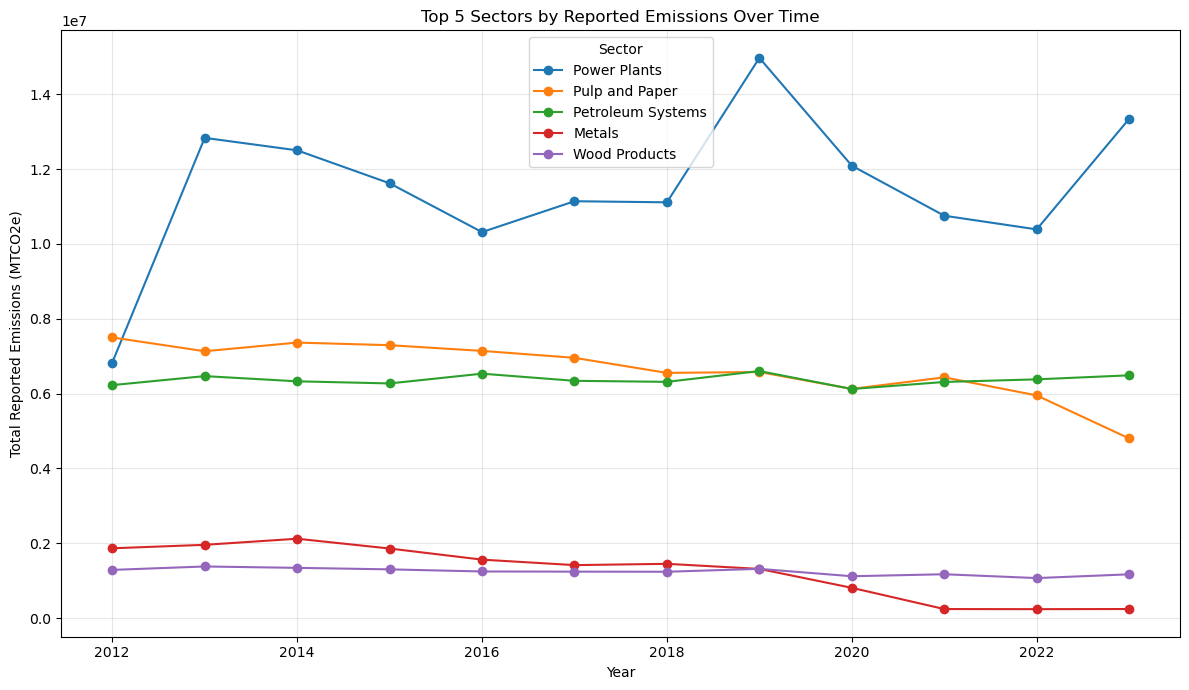

In [24]:
# TODO (Daniel Merced): Multi-line chart of emissions over time by sector
# Include legend, axis labels, title, and any annotations

plt.figure(figsize=(12, 7))

# Plot one line per top sector
for sector in top_5_sectors:
    sector_data = top_5_sector_trends[top_5_sector_trends["Sector"] == sector]
    plt.plot(
        sector_data["Year"],
        sector_data["Reported Emissions (MTCO2e)"],
        marker="o",
        label=sector
    )

plt.title("Top 5 Sectors by Reported Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("Total Reported Emissions (MTCO2e)")
plt.legend(title="Sector")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()  


*TODO (Daniel Merced): Write 2-3 sentences interpreting the trends visible in this chart.*

These are the top 5 sectors by reported emissions. Our top reported emissions contributor is the power sector, where despite the largest fluctuations over time has consistently maintained it's position above the other four. Pulp & Paper and Petrol are stable and are similar in reported emissions, the same is true for metals and wood products.

### Q3: Is there a relationship between county income and per-capita emissions? (Phakphoom)

Create a scatter plot with:
- X-axis: Median Household Income
- Y-axis: Per-capita emissions
- Optional: size or color by population

Label notable outlier counties. Does lower income correlate with higher emissions burden?

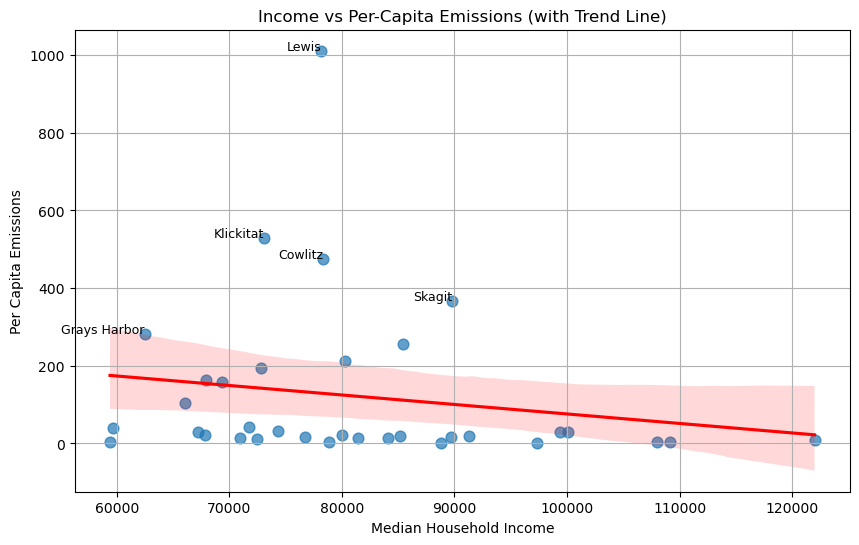

The correlation between Median Household Income and Per-Capita Emissions is -0.1713306914118599.


In [25]:
# Label key outlier counties, add title and axis labels

# Merge count level emissions with income data for scatter plot
county_emissions_by_income = county_emissions.join(
    ghg_population_income[['Median Household Income', "County"]]
    .drop_duplicates(subset="County")
    .set_index("County")
)

# Median Household Income vs Per-Capita Emissions scatter plot
plt.figure(figsize=(10, 6))

sns.regplot(
    data=county_emissions_by_income,
    x="Median Household Income",
    y="Per_Capita_Emissions",
    scatter_kws={"s": 60, "alpha": 0.7},
    line_kws={"color": "red"}
)

# Labeling top 3 outliers
top_outliers = county_emissions_by_income.sort_values(
    'Per_Capita_Emissions', ascending=False
).head(5)

for county, row in top_outliers.iterrows():
    plt.text(
        row['Median Household Income'],
        row['Per_Capita_Emissions'],
        county,
        fontsize=9,
        ha='right'
    )

# Labels and title
plt.title("Income vs Per-Capita Emissions (with Trend Line)")
plt.xlabel("Median Household Income")
plt.ylabel("Per Capita Emissions")

plt.grid(True)
plt.show()

corr = county_emissions_by_income["Median Household Income"].corr(
    county_emissions_by_income["Per_Capita_Emissions"]
)
print(f"The correlation between Median Household Income and Per-Capita Emissions is {corr}.")

The results suggest that per-capita emissions are not strongly associated with county income levels. The weak negative correlation indicates that income alone does not explain emissions patterns. Instead, emissions appear to be driven by the presence of large industrial facilities, which are unevenly distributed across counties. This leads to extreme per-capita values in certain lower-population counties, highlighting that structural and geographic factors play a more significant role than socioeconomic characteristics.

### Q4: Which sectors dominate emissions in the highest per-capita counties? (Veer)

Take the top 5 counties by per-capita emissions. Create a stacked bar chart showing the sector breakdown of emissions in each county. Are these counties dominated by one industry, or is the burden spread across sectors?

In [26]:
# TODO (Veer): Stacked bar chart — sector breakdown for top 5 per-capita counties
# Clear legend, title, and axis labels


*TODO (Veer): Write 2-3 sentences interpreting which industries drive the burden in high per-capita counties.*

---
## 7. Conclusion

*TODO (All): Summarize the key findings:*
- *How does the per-capita picture differ from the total emissions picture?*
- *What role does income play in who bears the emissions burden?*
- *Which sectors are the biggest contributors in the hardest-hit counties?*
- *What are the limitations of this analysis?*